In [1]:
import json
import pickle
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from sklearn.metrics import (
    roc_auc_score,
    f1_score,
    precision_score,
    recall_score,
    accuracy_score,
    confusion_matrix
)

In [2]:
ARTIFACT_DIR = Path("artifacts")
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
BATCH_SIZE = 64

print(f"Using Device : {DEVICE}")

Using Device : cpu


In [3]:
X_test = np.load(ARTIFACT_DIR / "X_test.npy")
Y_test = np.load(ARTIFACT_DIR / "Y_test.npy")

with open(ARTIFACT_DIR / "bacteria_encoder.pkl", "rb") as file:
    bacteria_encoder = pickle.load(file)

with open(ARTIFACT_DIR / "target_columns.json", "r") as file:
    target_columns = json.load(file)

In [4]:
class ClinicalDataset(Dataset):
    def __init__(self, X, Y):
        self.clinical = torch.tensor(
            X[:, :6],
            dtype=torch.float32
        )
        self.bacteria = torch.tensor(
            X[:, 6],
            dtype=torch.long
        )
        self.targets = torch.tensor(
            Y,
            dtype=torch.float32
        )

    def __len__(self):
        return len(self.targets)

    def __getitem__(self, index):
        return (
            self.clinical[index],
            self.bacteria[index],
            self.targets[index]
        )

test_dataset = ClinicalDataset(X_test, Y_test)
test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

In [6]:
class SentinelMultiTargetMLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.embedding = nn.Embedding(
            num_embeddings=len(bacteria_encoder.classes_),
            embedding_dim=4
        )
        self.clinical_layer = nn.Sequential(
            nn.Linear(6, 64),
            nn.BatchNorm1d(64),
            nn.ReLU()
        )
        self.classifier = nn.Sequential(
            nn.Linear(68, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.30),
            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(0.30),
            nn.Linear(64, 15)
        )

    def forward(self, clinical, bacteria):
        clinical_features = self.clinical_layer(clinical)
        bacteria_embedding = self.embedding(bacteria)
        combined = torch.cat(
            [clinical_features, bacteria_embedding],
            dim=1
        )
        logits = self.classifier(combined)
        return logits

model = SentinelMultiTargetMLP().to(DEVICE)
model.load_state_dict(
    torch.load(
        "best_model.pth",
        map_location=DEVICE
    )
)

<All keys matched successfully>

In [7]:
model.eval()

all_logits = []
all_targets = []

with torch.no_grad():
    for clinical, bacteria, targets in test_loader:
        clinical = clinical.to(DEVICE)
        bacteria = bacteria.to(DEVICE)

        logits = model(clinical, bacteria)

        all_logits.append(logits.cpu())
        all_targets.append(targets)

all_logits = torch.cat(all_logits)
all_targets = torch.cat(all_targets)

probabilities = torch.sigmoid(all_logits)

probabilities = probabilities.numpy()
targets = all_targets.numpy()

predictions = (probabilities >= 0.5).astype(int)

print(probabilities.shape)
print(predictions.shape)
print(targets.shape)

(1493, 15)
(1493, 15)
(1493, 15)


In [8]:
results = []

for i, antibiotic in enumerate(target_columns):
    true = targets[:, i]
    pred = predictions[:, i]
    prob = probabilities[:, i]

    # Ignore missing labels
    mask = ~np.isnan(true)

    true = true[mask]
    pred = pred[mask]
    prob = prob[mask]

    auc = roc_auc_score(true, prob)
    f1 = f1_score(true, pred)
    precision = precision_score(true, pred)
    recall = recall_score(true, pred)
    accuracy = accuracy_score(true, pred)

    results.append({
        "Antibiotic": antibiotic,
        "ROC-AUC": auc,
        "F1": f1,
        "Precision": precision,
        "Recall": recall,
        "Accuracy": accuracy
    })

results_df = pd.DataFrame(results)
results_df = results_df.round(3)
results_df

,Antibiotic,ROC-AUC,F1,Precision,Recall,Accuracy
0,AMX/AMP,0.659,0.734,0.705,0.765,0.676
1,AMC,0.658,0.719,0.708,0.731,0.662
2,CZ,0.659,0.710,0.699,0.722,0.650
3,FOX,0.675,0.727,0.702,0.755,0.672
4,CTX/CRO,0.673,0.724,0.712,0.736,0.663
5,IPM,0.676,0.727,0.716,0.739,0.670
6,GEN,0.505,0.277,0.214,0.392,0.574
7,AN,0.509,0.276,0.215,0.389,0.597
8,Acide nalidixique,0.585,0.304,0.197,0.665,0.488
9,ofx,0.595,0.307,0.197,0.699,0.480


In [9]:
results_df.describe()

print(results_df.mean(numeric_only=True))

ROC-AUC      0.615867
F1           0.473733
Precision    0.405200
Recall       0.695467
Accuracy     0.572800
dtype: float64


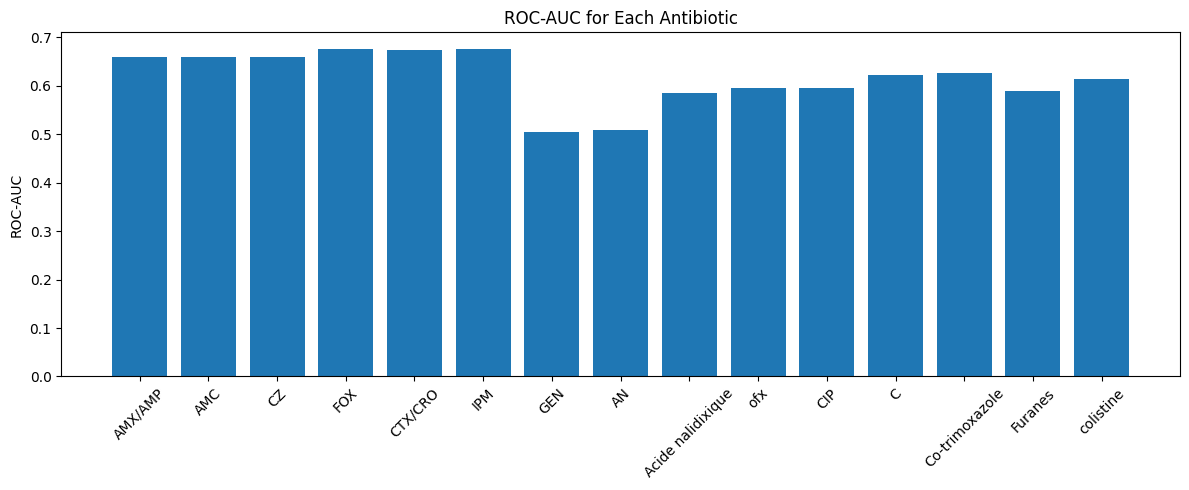

In [10]:
plt.figure(figsize=(12,5))

plt.bar(
    results_df["Antibiotic"],
    results_df["ROC-AUC"]
)

plt.xticks(rotation=45)
plt.ylabel("ROC-AUC")
plt.title("ROC-AUC for Each Antibiotic")
plt.tight_layout()
plt.show()

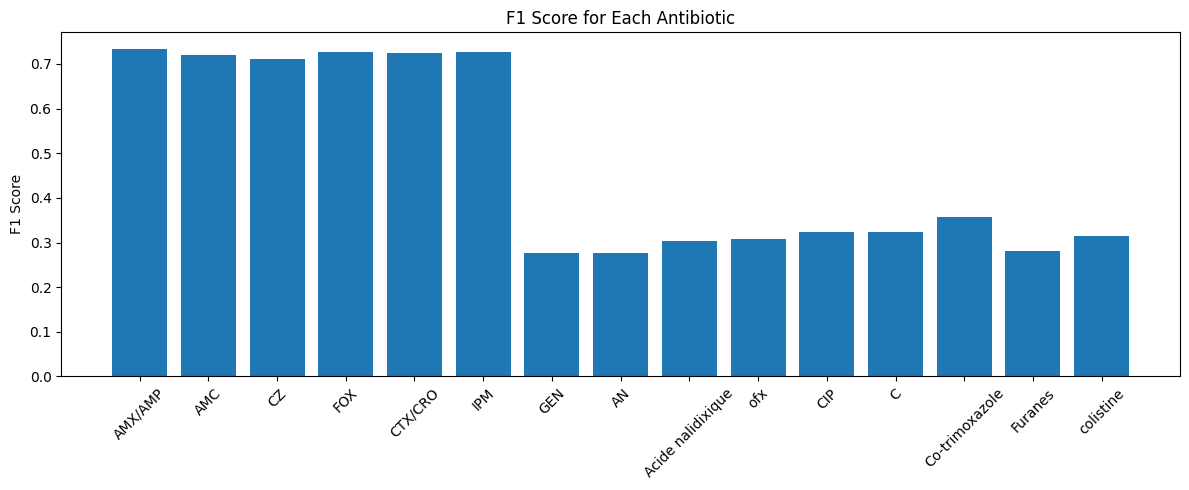

In [11]:
plt.figure(figsize=(12,5))

plt.bar(
    results_df["Antibiotic"],
    results_df["F1"]
)

plt.xticks(rotation=45)
plt.ylabel("F1 Score")
plt.title("F1 Score for Each Antibiotic")
plt.tight_layout()
plt.show()

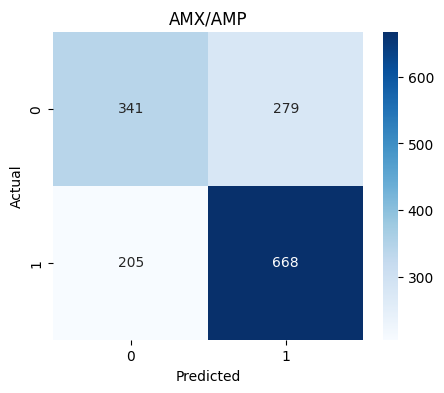

In [12]:
drug = 0

mask = ~np.isnan(targets[:, drug])

cm = confusion_matrix(
    targets[:, drug][mask],
    predictions[:, drug][mask]
)

plt.figure(figsize=(5,4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title(target_columns[drug])
plt.show()

In [13]:
results_df.to_csv(
    ARTIFACT_DIR / "test_results.csv",
    index=False
)